# 03 · Synthetic event generation — Gaussian copula

A Gaussian copula (implemented with OpenTURNS, Baudin et al., 2016) is fitted to **68 variables**: the four parameters (Pmax, Pmed, Duration, Type) of each of the 17 gauges. The copula models both the inter-variable dependence within each gauge and the spatial correlation across gauges.  

**~1 million** synthetic events are generated simultaneously across all gauges. Figures 6 and 7 in Navas et al. (2024) show results for a **single gauge (P_27)** in the (Pmax, Pmed, Duration, Type) space.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'm30_manzanares'

EVENTS_DIR   = DATA_ROOT / 'events'
RESULTS_DIR  = DATA_ROOT / 'results'
STATIONS_DIR = DATA_ROOT / 'stations'

print('DATA_ROOT:', DATA_ROOT)

T_VALS   = [2, 5, 10, 20, 50, 100, 500]
N_STAT   = 17
LAM      = 5.17    # Poisson rate (events/year)
XS_PT    = 6262    # Toledo Bridge cross-section
XS_R9    = 4112    # Weir No.9 cross-section


DATA_ROOT: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/m30_manzanares


Synthetic selected events (proxy, original 1,761 historical not available): 930
Synthetic sample (~1M generated by copula):  10,000


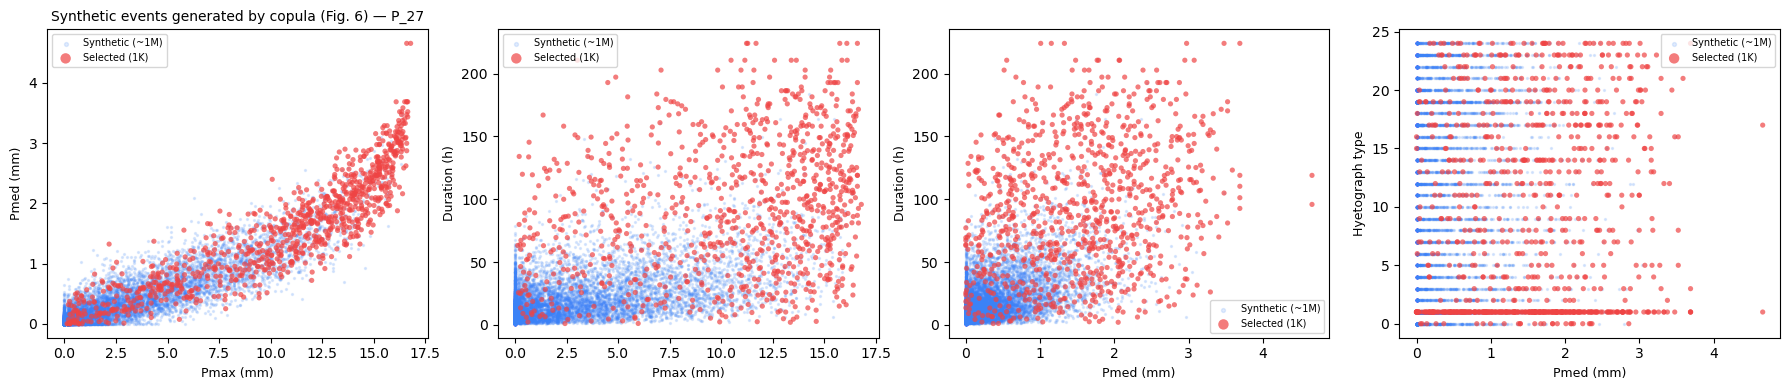

In [2]:
events = pd.read_csv(EVENTS_DIR / 'events_selected.csv', index_col=0)
synth  = pd.read_csv(EVENTS_DIR / 'events_synthetic_sample.csv', index_col=0)

# Gauge P_27 (station 1) — reference in the paper (Figures 6 & 7)
sel  = events[['Pmax1','Pmed1','Duracion1','Tipo1']].copy()
samp = synth[['Pmax1','Pmed1','Duracion1','Tipo1']].copy()

sel_nz = sel[sel['Pmax1'] > 0]   # exclude zero-Pmax entries (gauge inactive)

print(f'Synthetic selected events (proxy, original 1,761 historical not available): {len(sel_nz)}')
print(f'Synthetic sample (~1M generated by copula):  {len(samp):,}')

# Reproduce Figure 6 from Navas et al. (2024) — 4 scatter plots for P_27
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

pairs = [
    ('Pmax1',    'Pmed1',     'Pmax (mm)',    'Pmed (mm)'),
    ('Pmax1',    'Duracion1', 'Pmax (mm)',    'Duration (h)'),
    ('Pmed1',    'Duracion1', 'Pmed (mm)',    'Duration (h)'),
    ('Pmed1',    'Tipo1',     'Pmed (mm)',    'Hyetograph type'),
]

for ax, (xc, yc, xl, yl) in zip(axes, pairs):
    ax.scatter(samp[xc], samp[yc], s=2, alpha=0.15, c='#3b82f6',
               label='Synthetic (~1M)', rasterized=True)
    ax.scatter(sel_nz[xc], sel_nz[yc], s=14, alpha=0.7, c='#ef4444',
               edgecolors='none', label='Selected (1K)', zorder=3)
    ax.set_xlabel(xl, fontsize=9); ax.set_ylabel(yl, fontsize=9)
    ax.legend(fontsize=7, markerscale=2)

axes[0].set_title('Synthetic events generated by copula (Fig. 6) — P_27', fontsize=10)
plt.tight_layout(); plt.show()

## Marginal distribution fitting

Each variable is fitted to its best marginal distribution before entering the copula. The fitted CDF transforms the variable to the uniform [0,1] space.

In [3]:
from scipy.stats import expon, weibull_min, lognorm, gamma

data = events['Pmax1'].values
data = data[data > 0]

fits  = {'Exponential': (expon,       expon.fit(data, floc=0)),
         'Weibull':     (weibull_min,  weibull_min.fit(data, floc=0)),
         'LogNormal':   (lognorm,      lognorm.fit(data, floc=0)),
         'Gamma':       (gamma,        gamma.fit(data, floc=0))}

x     = np.linspace(0.01, data.max()*1.1, 300)
best  = None; best_aic = np.inf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data, bins=35, density=True, alpha=0.6,
             color='#94a3b8', edgecolor='k', lw=0.3, label='Data')
for name, (dist, params) in fits.items():
    logL = np.sum(dist.logpdf(data, *params))
    aic  = 2*len(params) - 2*logL
    axes[0].plot(x, dist.pdf(x, *params), lw=1.8, label=f'{name} (AIC={aic:.0f})')
    if aic < best_aic: best_aic, best = aic, (name, dist, params)

axes[0].set_xlabel('Pmax P_27 (mm)'); axes[0].set_ylabel('Density')
axes[0].set_title('Marginal distribution fit — Pmax P_27')
axes[0].legend(fontsize=8)

# Return period curve — note: uses the 1,000 MaxDiss-selected events as proxy
# (original 1,761 historical events are not redistributed here)
name, dist, params = best
sorted_d = np.sort(data)[::-1]
T_emp    = (len(sorted_d)+1) / np.arange(1, len(sorted_d)+1) / LAM
T_fit    = np.logspace(np.log10(1.01/LAM), np.log10(500), 200)
q_fit    = dist.ppf(np.clip(1 - 1/(T_fit*LAM), 0, 0.9999), *params)

axes[1].scatter(T_emp, sorted_d, s=15, alpha=0.5, color='#94a3b8', label='Selected events (proxy)')
axes[1].plot(T_fit, q_fit, '-', lw=2.5, color='#3b82f6', label=f'Best fit: {name} (AIC={best_aic:.0f})')
axes[1].set_xscale('log')
axes[1].set_xlabel('Return period T (years)')
axes[1].set_ylabel('Pmax P_27 (mm)')
axes[1].set_title('Return period curve — Pmax P_27')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].text(0.97, 0.04,
             'Note: marginals fitted on MaxDiss-selected events\n(not on the original 1,761 historical series)',
             transform=axes[1].transAxes, ha='right', va='bottom',
             fontsize=7.5, color='#6b7280',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, lw=0))
plt.tight_layout(); plt.show()